# Peripheral Strategy Backtest

This notebook tests the following specific signal:
- **Long** the peripheral stocks when the central portfolio's lagged return is positive.
- **Short** the peripheral stocks when the central portfolio's lagged return is negative.

The central and peripheral portfolios are created by stacking all out-of-sample years into one continuous series for each estimation window $k$ ($k=1$ and $k=10$). We then report the Annualized Return and Sharpe Ratio of this signal.

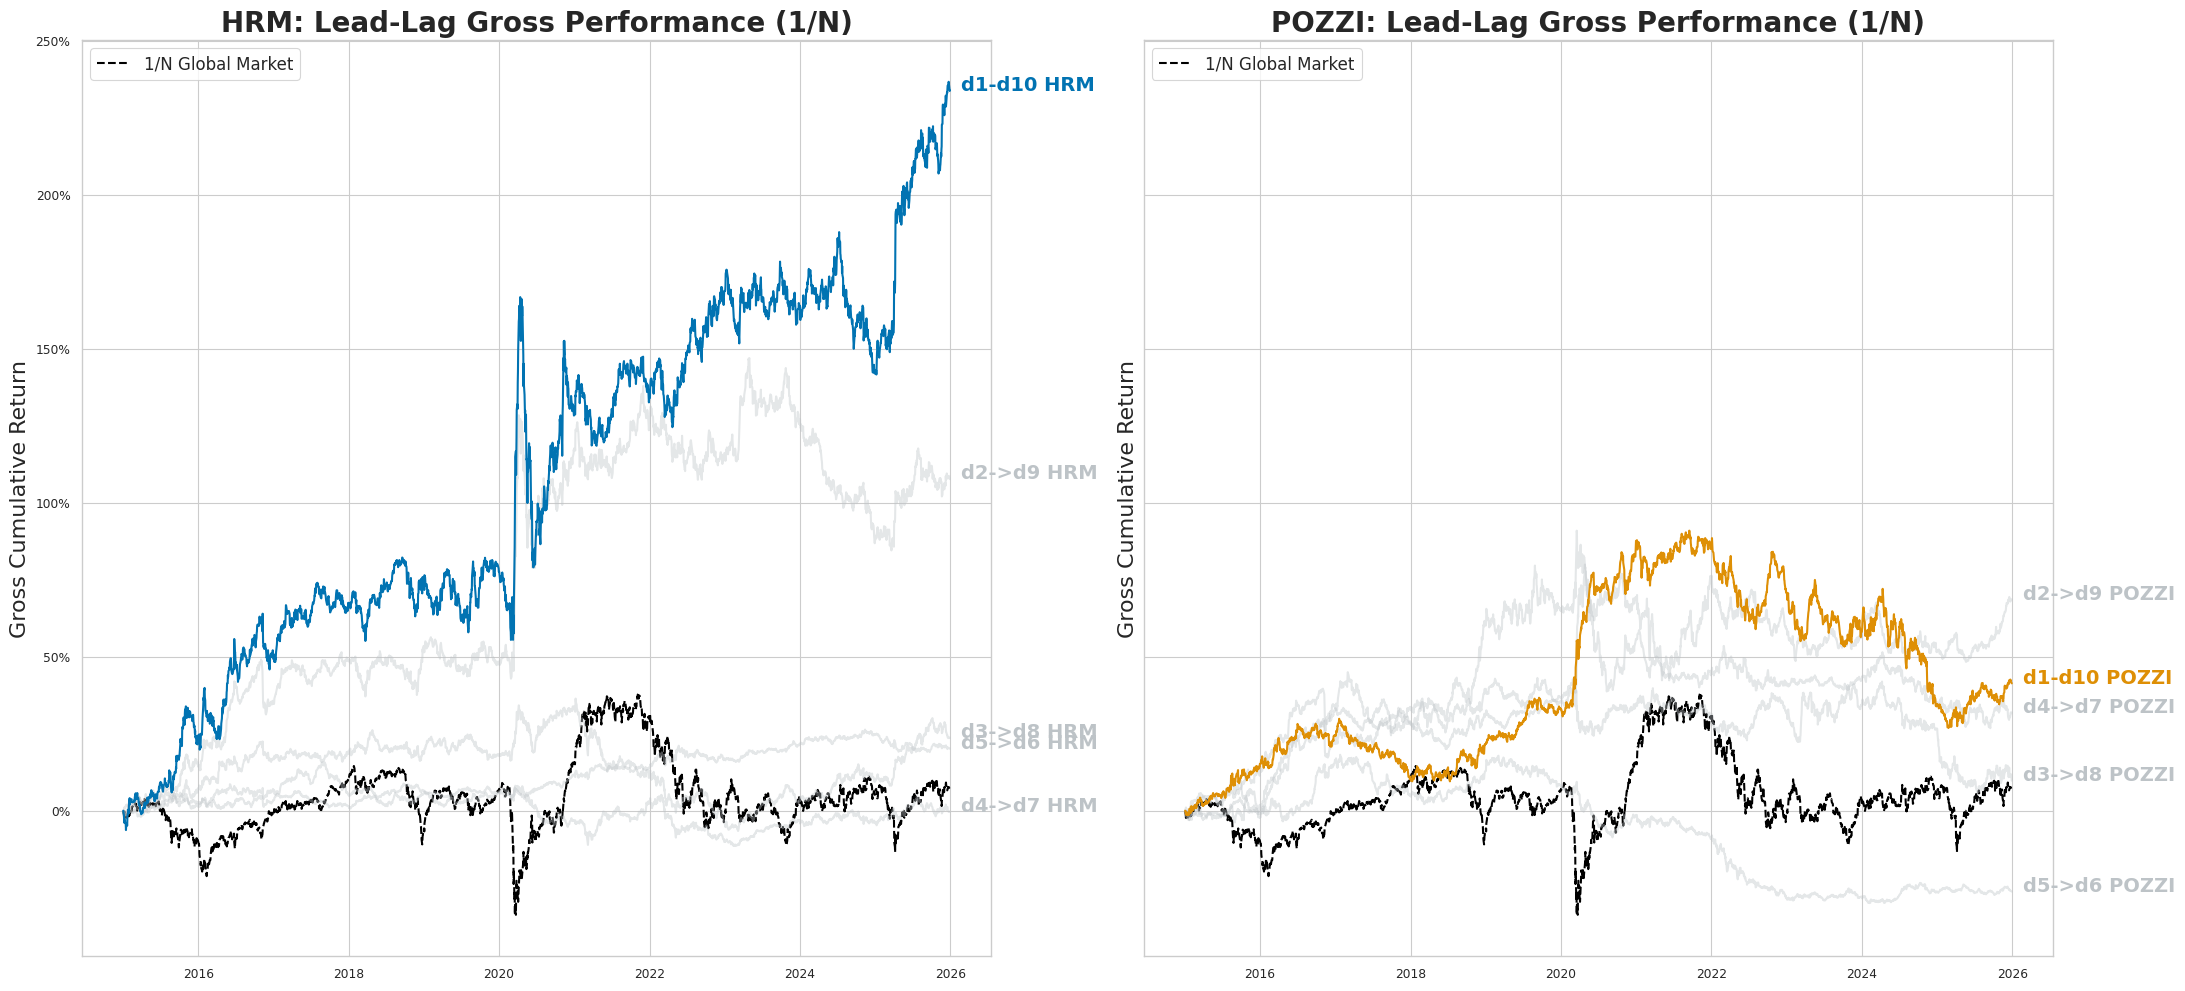

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO ---
years = range(2014, 2025)
k = 5
metrics = ["hrm", "pozzi"]
decile_pairs = [(i, 11 - i) for i in range(1, 6)] 

# 1. Carregamento do Universo Total
df_ret_full = pd.read_parquet("../../data/01_raw/returns.parquet")
df_ret_full = df_ret_full[df_ret_full.index >= pd.Timestamp(2015, 1, 1)]

# Benchmark 1/N Global (Média simples de todos os ativos disponíveis)
# Identifica a partir de quando cada ativo comeca a ter retornos
is_active = df_ret_full.notna() & (df_ret_full != 0).cummax()
# Calcula o benchmark considerando apenas os ativos ja listados
market_benchmark_global = np.log1p(df_ret_full.where(is_active)).mean(axis=1)

results_strat = {m: {f"d{p}_d{c}": [] for p, c in decile_pairs} for m in metrics}

# --- LOOP DE BACKTEST (OUT-OF-SAMPLE) ---
for year in years:
    test_year = year + 1
    df_ret_oos = df_ret_full[df_ret_full.index.year == test_year]
    
    if df_ret_oos.empty:
        continue

    for metric in metrics:
        for c_idx, p_idx in decile_pairs:
            try:
                # Identificação dos decis formados no ano de treino
                c_label = f"decil_{c_idx}_{year}_{metric}"
                p_label = f"decil_{p_idx}_{year}_{metric}"
                
                cols_c = pd.read_parquet(f"../../data/06_portfolios/{c_label}.parquet").columns
                cols_p = pd.read_parquet(f"../../data/06_portfolios/{p_label}.parquet").columns
                
                # Sincronização com o que é negociável no período OOS
                valid_c = cols_c.intersection(df_ret_oos.columns)
                valid_p = cols_p.intersection(df_ret_oos.columns)

                # 2. CÁLCULO 1/N (Média Simples)
                ret_c = np.log1p(df_ret_oos[valid_c]).mean(axis=1)
                ret_p = np.log1p(df_ret_oos[valid_p]).mean(axis=1)

                # --- ESTRATÉGIA LEAD-LAG BRUTA (GROSS RETURNS) ---
                # Sinal baseado na diferenca entre o lider e o liderado (Spread)
                signal = np.sign((ret_c - ret_p).shift(1)).fillna(0)
                
                # Spread PMC: Peripheral Minus Central (Neutralizando Beta)
                # Sem custos de transação (Gross of Fees)
                strat_ret = signal * (ret_p - ret_c)
                
                results_strat[metric][f"d{c_idx}_d{p_idx}"].append(strat_ret)
                
            except FileNotFoundError:
                continue

# --- CONSOLIDAÇÃO ---
final_results = {}
for m in metrics:
    for pair_key in results_strat[m]:
        if results_strat[m][pair_key]:
            final_results[f"{m}_{pair_key}"] = pd.concat(results_strat[m][pair_key])

# --- VISUALIZAÇÃO ---
sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(1, 2, figsize=(22, 10), sharey=True)
palette = sns.color_palette("colorblind")

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # 1/N Market Benchmark (Global)
    common_idx = final_results[f"{metric}_d1_d10"].index
    mkt_plot = market_benchmark_global.loc[common_idx]
    cum_market = np.exp(mkt_plot.cumsum()) - 1
    ax.plot(cum_market.index, cum_market, color='black', lw=1.5, ls='--', label='1/N Global Market')

    # Pares Intermediários (Visual 'Faded')
    for c_idx, p_idx in decile_pairs[1:]:
        pair_key = f"{metric}_d{c_idx}_d{p_idx}"
        if pair_key in final_results:
            rets = final_results[pair_key]
            cum_rets = np.exp(rets.cumsum()) - 1
            ax.plot(cum_rets.index, cum_rets, color='#BDC3C7', lw=1.5, alpha=0.4)
            ax.annotate(f"d{c_idx}->d{p_idx} {metric.upper()}", xy=(cum_rets.index[-1], cum_rets.iloc[-1]), 
                xytext=(8, 0), textcoords='offset points', fontsize=14, fontweight='bold', color='#BDC3C7')

    # Par Principal (d1 Central vs d10 Peripheral)
    pair_main = f"{metric}_d1_d10"
    if pair_main in final_results:
        rets = final_results[pair_main]
        cum_rets = np.exp(rets.cumsum()) - 1
        ax.plot(cum_rets.index, cum_rets, color=palette[idx], lw=1.5, zorder=5)
        
        # Labeling
        ax.annotate(f"d1-d10 {metric.upper()}", xy=(cum_rets.index[-1], cum_rets.iloc[-1]), 
                    xytext=(8, 0), textcoords='offset points', fontsize=14, fontweight='bold', color=palette[idx])

    ax.set_title(f"{metric.upper()}: Lead-Lag Gross Performance (1/N)", fontsize=20, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel("Gross Cumulative Return", fontsize=16)
    ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig("../../figures/strategy_gross_1n.png", dpi=300)
plt.show()

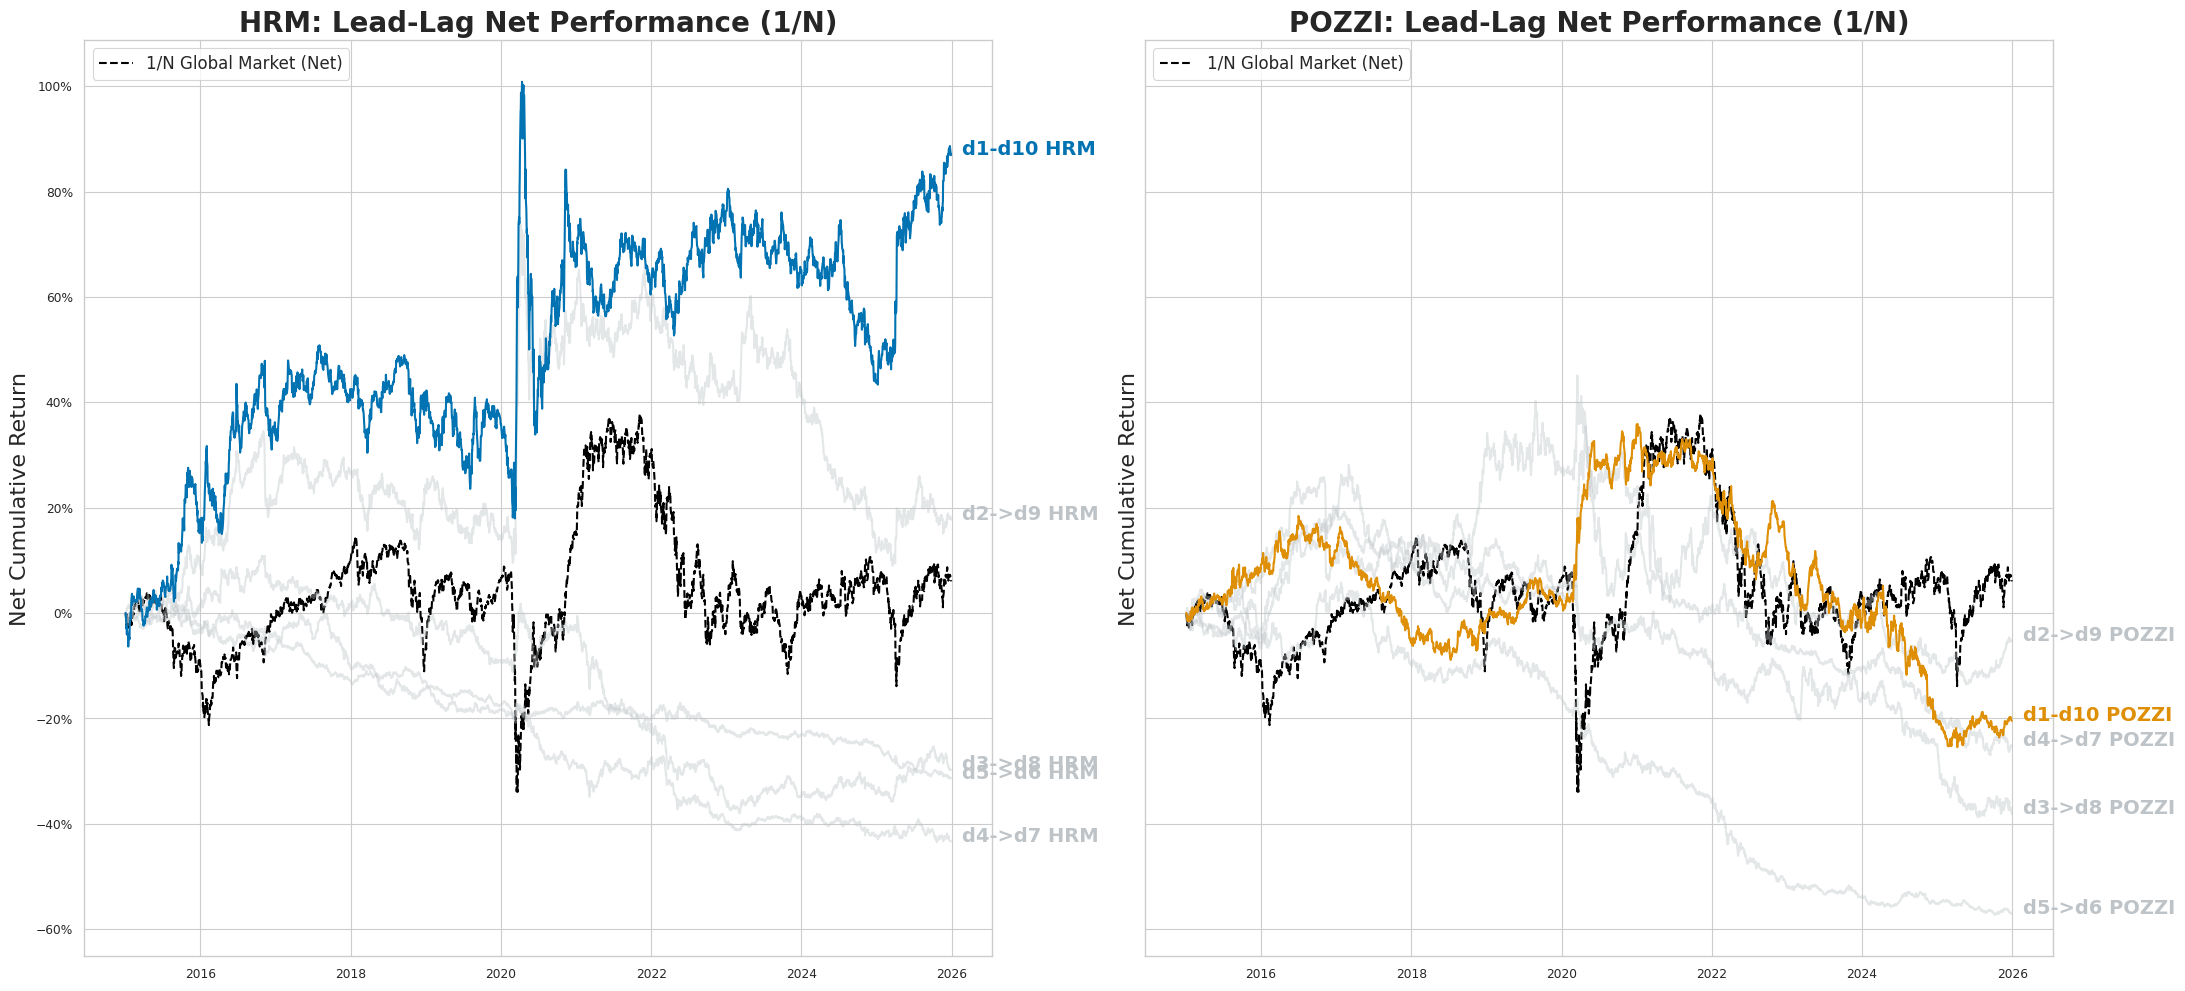

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO ---
years = range(2014, 2025)
k = 5
metrics = ["hrm", "pozzi"]
decile_pairs = [(i, 11 - i) for i in range(1, 6)] 
c = 0.0001 # Custo de transação (10 bps). Altere se desejar (ex: 0.0005 para 5 bps).

# 1. Carregamento do Universo Total
df_ret_full = pd.read_parquet("../../data/01_raw/returns.parquet")
df_ret_full = df_ret_full[df_ret_full.index >= pd.Timestamp(2015, 1, 1)]

# --- BENCHMARK 1/N GLOBAL COM CUSTOS DE TRANSAÇÃO ---
# Identifica a partir de quando cada ativo começa a ter retornos
is_active = df_ret_full.notna() & (df_ret_full != 0).cummax()

# Pesos alvo do benchmark (1/N para ativos ativos no dia t)
W_mkt = is_active.astype(float).div(is_active.sum(axis=1), axis=0)
R_mkt_all = df_ret_full.fillna(0)

# Pesos após o drift do mercado (pesos do dia t-1 crescendo com o retorno do dia t-1)
W_mkt_drift = W_mkt.shift(1) * (1 + R_mkt_all.shift(1))
W_mkt_drift = W_mkt_drift.div(W_mkt_drift.sum(axis=1), axis=0)

# Turnover diário do benchmark para rebalancear de volta a 1/N
turnover_mkt = (W_mkt - W_mkt_drift).abs().sum(axis=1).fillna(0)

# Retorno líquido do benchmark (Descontando o custo dos trades feitos no início do dia)
market_benchmark_global_gross = np.log1p(df_ret_full.where(is_active)).mean(axis=1)
market_benchmark_global = market_benchmark_global_gross - (c * turnover_mkt)

results_strat = {m: {f"d{p}_d{c}": [] for p, c in decile_pairs} for m in metrics}

# --- LOOP DE BACKTEST (OUT-OF-SAMPLE) ---
for year in years:
    test_year = year + 1
    df_ret_oos = df_ret_full[df_ret_full.index.year == test_year]
    
    if df_ret_oos.empty:
        continue

    for metric in metrics:
        for c_idx, p_idx in decile_pairs:
            try:
                # Identificação dos decis formados no ano de treino
                c_label = f"decil_{c_idx}_{year}_{metric}"
                p_label = f"decil_{p_idx}_{year}_{metric}"
                
                cols_c = pd.read_parquet(f"../../data/06_portfolios/{c_label}.parquet").columns
                cols_p = pd.read_parquet(f"../../data/06_portfolios/{p_label}.parquet").columns
                
                # Sincronização com o que é negociável no período OOS
                valid_c = cols_c.intersection(df_ret_oos.columns)
                valid_p = cols_p.intersection(df_ret_oos.columns)

                # 2. CÁLCULO 1/N (Média Simples)
                ret_c = np.log1p(df_ret_oos[valid_c]).mean(axis=1)
                ret_p = np.log1p(df_ret_oos[valid_p]).mean(axis=1)

                # --- ESTRATÉGIA LEAD-LAG BRUTA (GROSS RETURNS) ---
                # Sinal baseado na diferença entre o líder e o liderado (Spread)
                signal = np.sign((ret_c - ret_p).shift(1)).fillna(0)
                
                # Spread PMC: Peripheral Minus Central (Neutralizando Beta)
                strat_ret_gross = signal * (ret_p - ret_c)
                
                # --- CUSTOS DE TRANSAÇÃO DA ESTRATÉGIA ---
                # Pesos alvo de cada perna da estratégia no dia t
                W_p_target = pd.DataFrame(1/len(valid_p), index=df_ret_oos.index, columns=valid_p).multiply(signal, axis=0)
                W_c_target = pd.DataFrame(1/len(valid_c), index=df_ret_oos.index, columns=valid_c).multiply(-signal, axis=0)
                
                # Junta os pesos em um DataFrame único (se houver ativos na interseção, eles se anulam via .add)
                W_target = W_p_target.add(W_c_target, fill_value=0)
                
                # Calcula os pesos driftados do dia t-1 (antes de sofrerem o rebalanceamento no início de t)
                R_oos = df_ret_oos[W_target.columns].fillna(0)
                W_drift = W_target.shift(1) * (1 + R_oos.shift(1))
                
                # Turnover absoluto da estratégia (incluindo inversão de sinais + drift interno de 1/N)
                turnover_strat = (W_target - W_drift).abs().sum(axis=1).fillna(0)
                
                # Retorno Líquido
                strat_ret_net = strat_ret_gross - (c * turnover_strat)
                
                results_strat[metric][f"d{c_idx}_d{p_idx}"].append(strat_ret_net)
                
            except FileNotFoundError:
                continue

# --- CONSOLIDAÇÃO ---
final_results = {}
for m in metrics:
    for pair_key in results_strat[m]:
        if results_strat[m][pair_key]:
            final_results[f"{m}_{pair_key}"] = pd.concat(results_strat[m][pair_key])

# --- VISUALIZAÇÃO ---
sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(1, 2, figsize=(22, 10), sharey=True)
palette = sns.color_palette("colorblind")

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # 1/N Market Benchmark (Global)
    common_idx = final_results[f"{metric}_d1_d10"].index
    mkt_plot = market_benchmark_global.loc[common_idx]
    cum_market = np.exp(mkt_plot.cumsum()) - 1
    ax.plot(cum_market.index, cum_market, color='black', lw=1.5, ls='--', label='1/N Global Market (Net)')

    # Pares Intermediários (Visual 'Faded')
    for c_idx, p_idx in decile_pairs[1:]:
        pair_key = f"{metric}_d{c_idx}_d{p_idx}"
        if pair_key in final_results:
            rets = final_results[pair_key]
            cum_rets = np.exp(rets.cumsum()) - 1
            ax.plot(cum_rets.index, cum_rets, color='#BDC3C7', lw=1.5, alpha=0.4)
            ax.annotate(f"d{c_idx}->d{p_idx} {metric.upper()}", xy=(cum_rets.index[-1], cum_rets.iloc[-1]), 
                xytext=(8, 0), textcoords='offset points', fontsize=14, fontweight='bold', color='#BDC3C7')

    # Par Principal (d1 Central vs d10 Peripheral)
    pair_main = f"{metric}_d1_d10"
    if pair_main in final_results:
        rets = final_results[pair_main]
        cum_rets = np.exp(rets.cumsum()) - 1
        ax.plot(cum_rets.index, cum_rets, color=palette[idx], lw=1.5, zorder=5)
        
        # Labeling
        ax.annotate(f"d1-d10 {metric.upper()}", xy=(cum_rets.index[-1], cum_rets.iloc[-1]), 
                    xytext=(8, 0), textcoords='offset points', fontsize=14, fontweight='bold', color=palette[idx])

    ax.set_title(f"{metric.upper()}: Lead-Lag Net Performance (1/N)", fontsize=20, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel("Net Cumulative Return", fontsize=16)
    ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig("../../figures/strategy_net_1n.png", dpi=300)
plt.show()

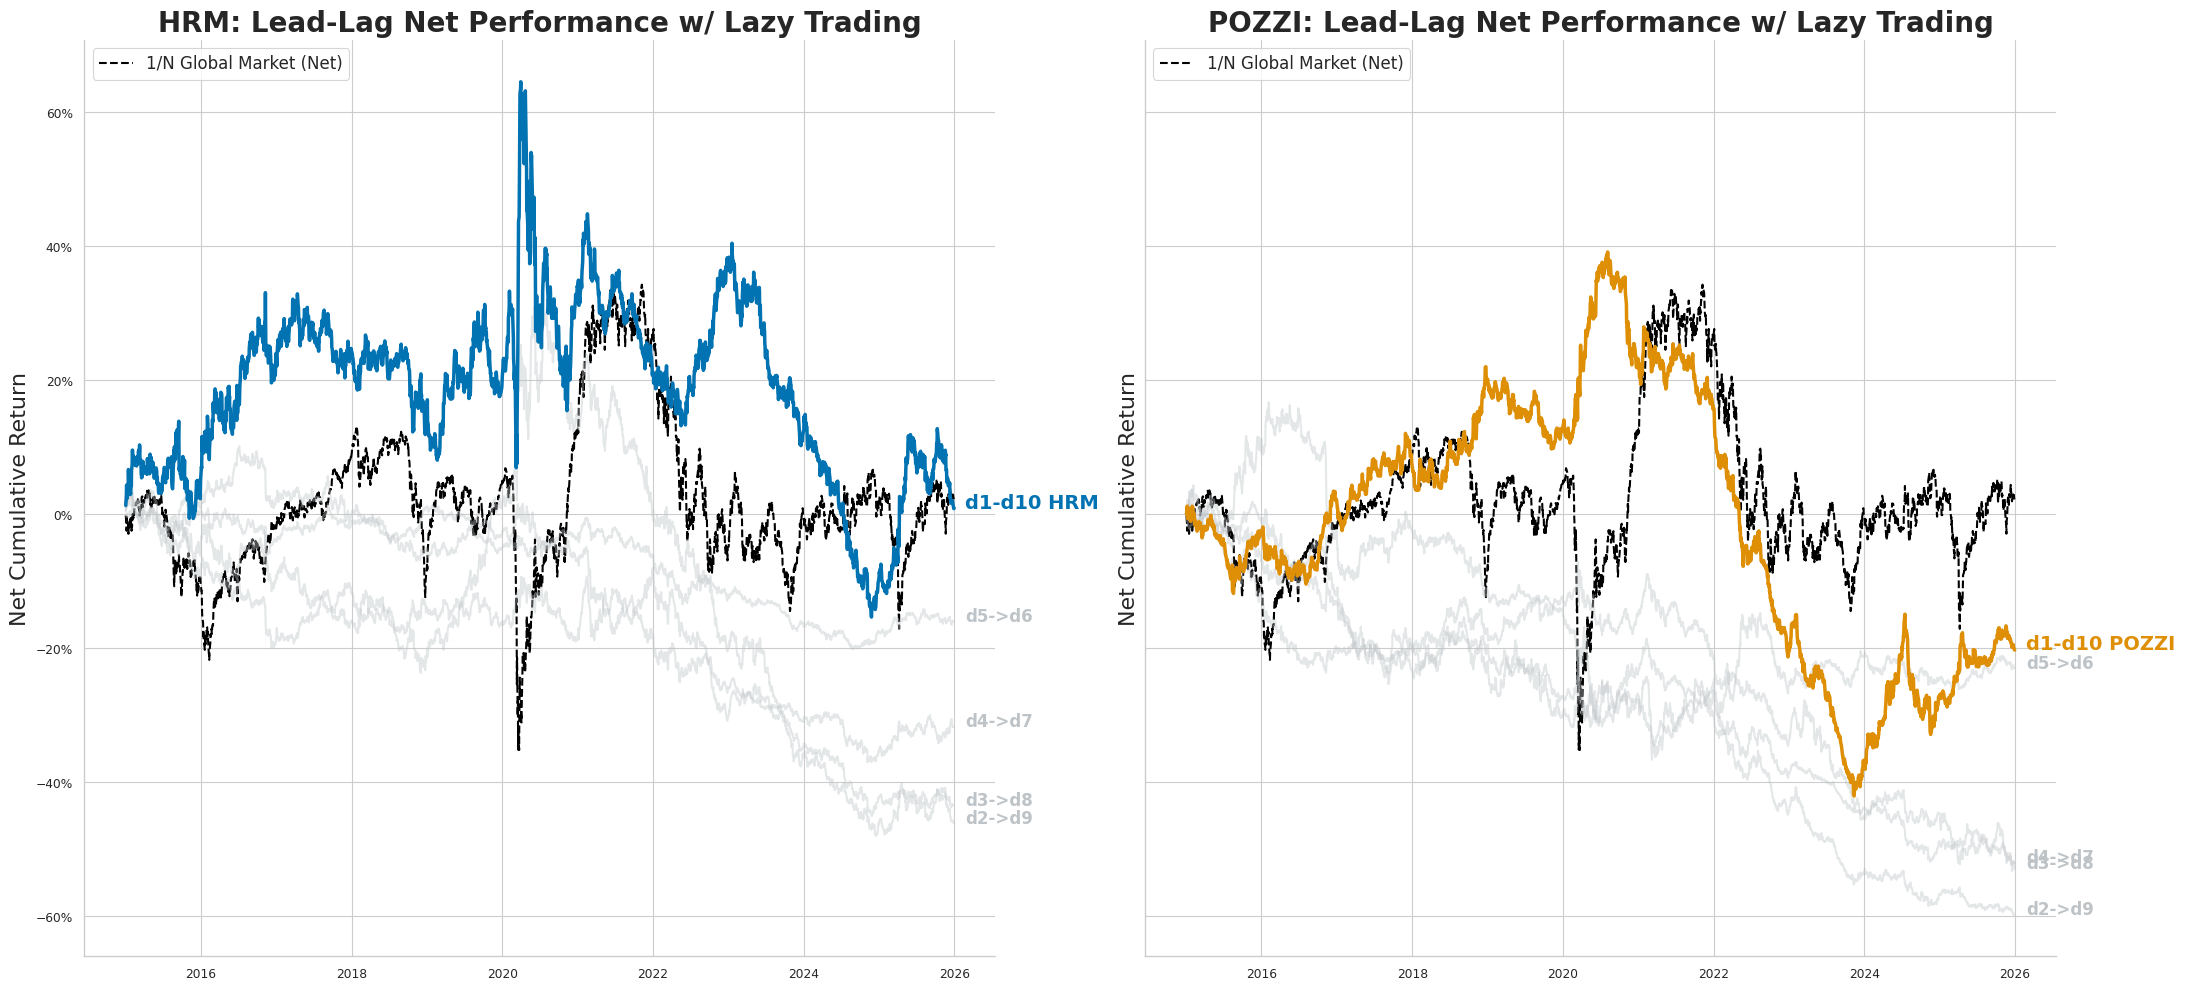

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO ---
years = range(2014, 2025)
k = 5
metrics = ["hrm", "pozzi"]
decile_pairs = [(i, 11 - i) for i in range(1, 6)] 
c = 0.001 # Custo de transação (10 bps)
threshold = 0.02 # Limite de inércia corrigido (20 bps). 

def generate_lazy_signal(spread_series, threshold):
    """
    Gera um sinal de negociação usando histerese (bandas de inércia).
    Sempre começa posicionado (1 ou -1) e SÓ TROCA se o spread cruzar a banda oposta.
    """
    signal = np.zeros(len(spread_series))
    
    # Pega o primeiro spread do ano para definir se começa Long ou Short.
    # Isso garante que a estratégia NUNCA fique zerada "sem querer".
    first_s = spread_series.iloc[0]
    current_pos = 1 if first_s >= 0 else -1
    
    for i in range(len(spread_series)):
        s = spread_series.iloc[i]
        
        # Só vira a mão se o spread for FORTE o suficiente
        if s > threshold:
            current_pos = 1
        elif s < -threshold:
            current_pos = -1
        # Se estiver no meio da banda, current_pos NÃO MUDA. 
        # (Se estava 1, continua 1. Se estava -1, continua -1. Zero turnover!)
        
        signal[i] = current_pos
        
    return pd.Series(signal, index=spread_series.index)


# 1. Carregamento do Universo Total
df_ret_full = pd.read_parquet("../../data/01_raw/returns.parquet")
df_ret_full = df_ret_full[df_ret_full.index >= pd.Timestamp(2015, 1, 1)]

# --- BENCHMARK 1/N GLOBAL COM CUSTOS DE TRANSAÇÃO ---
is_active = df_ret_full.notna() & (df_ret_full != 0).cummax()
W_mkt = is_active.astype(float).div(is_active.sum(axis=1), axis=0)
R_mkt_all = df_ret_full.fillna(0)

W_mkt_drift = W_mkt.shift(1).fillna(0) * (1 + R_mkt_all.shift(1).fillna(0))
W_mkt_drift = W_mkt_drift.div(W_mkt_drift.sum(axis=1).replace(0, 1), axis=0)

turnover_mkt = (W_mkt - W_mkt_drift).abs().sum(axis=1).fillna(0)
market_benchmark_global_gross = np.log1p(df_ret_full.where(is_active)).mean(axis=1)
market_benchmark_global = market_benchmark_global_gross - (c * turnover_mkt)

results_strat = {m: {f"d{p}_d{c}": [] for p, c in decile_pairs} for m in metrics}

# --- LOOP DE BACKTEST (OUT-OF-SAMPLE) ---
for year in years:
    test_year = year + 1
    df_ret_oos = df_ret_full[df_ret_full.index.year == test_year]
    
    if df_ret_oos.empty:
        continue

    for metric in metrics:
        for c_idx, p_idx in decile_pairs:
            try:
                c_label = f"decil_{c_idx}_{year}_{metric}"
                p_label = f"decil_{p_idx}_{year}_{metric}"
                
                cols_c = pd.read_parquet(f"../../data/06_portfolios/{c_label}.parquet").columns
                cols_p = pd.read_parquet(f"../../data/06_portfolios/{p_label}.parquet").columns
                
                valid_c = cols_c.intersection(df_ret_oos.columns)
                valid_p = cols_p.intersection(df_ret_oos.columns)

                ret_c = np.log1p(df_ret_oos[valid_c]).mean(axis=1)
                ret_p = np.log1p(df_ret_oos[valid_p]).mean(axis=1)

                # --- ESTRATÉGIA COM LAZY SIGNAL (HISTERESE) ---
                spread = (ret_c - ret_p).shift(1).fillna(0)
                signal = generate_lazy_signal(spread, threshold)
                
                strat_ret_gross = signal * (ret_p - ret_c)
                
                # --- CUSTOS DE TRANSAÇÃO DA ESTRATÉGIA ---
                W_p_target = pd.DataFrame(1/len(valid_p), index=df_ret_oos.index, columns=valid_p).multiply(signal, axis=0)
                W_c_target = pd.DataFrame(1/len(valid_c), index=df_ret_oos.index, columns=valid_c).multiply(-signal, axis=0)
                W_target = W_p_target.add(W_c_target, fill_value=0)
                
                R_oos = df_ret_oos[W_target.columns].fillna(0)
                
                # O fillna garante que paguemos o custo de montar a carteira no dia 1 do ano
                W_drift = W_target.shift(1).fillna(0) * (1 + R_oos.shift(1).fillna(0))
                
                turnover_strat = (W_target - W_drift).abs().sum(axis=1).fillna(0)
                strat_ret_net = strat_ret_gross - (c * turnover_strat)
                
                results_strat[metric][f"d{c_idx}_d{p_idx}"].append(strat_ret_net)
                
            except FileNotFoundError:
                continue

# --- CONSOLIDAÇÃO ---
final_results = {}
for m in metrics:
    for pair_key in results_strat[m]:
        if results_strat[m][pair_key]:
            final_results[f"{m}_{pair_key}"] = pd.concat(results_strat[m][pair_key])

# --- VISUALIZAÇÃO ---
sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(1, 2, figsize=(22, 10), sharey=True)
palette = sns.color_palette("colorblind")

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    common_idx = final_results[f"{metric}_d1_d10"].index
    mkt_plot = market_benchmark_global.loc[common_idx]
    cum_market = np.exp(mkt_plot.cumsum()) - 1
    ax.plot(cum_market.index, cum_market, color='black', lw=1.5, ls='--', label='1/N Global Market (Net)')

    for c_idx, p_idx in decile_pairs[1:]:
        pair_key = f"{metric}_d{c_idx}_d{p_idx}"
        if pair_key in final_results:
            rets = final_results[pair_key]
            cum_rets = np.exp(rets.cumsum()) - 1
            ax.plot(cum_rets.index, cum_rets, color='#BDC3C7', lw=1.5, alpha=0.4)
            ax.annotate(f"d{c_idx}->d{p_idx}", xy=(cum_rets.index[-1], cum_rets.iloc[-1]), 
                xytext=(8, 0), textcoords='offset points', fontsize=12, fontweight='bold', color='#BDC3C7')

    pair_main = f"{metric}_d1_d10"
    if pair_main in final_results:
        rets = final_results[pair_main]
        cum_rets = np.exp(rets.cumsum()) - 1
        ax.plot(cum_rets.index, cum_rets, color=palette[idx], lw=2.5, zorder=5)
        ax.annotate(f"d1-d10 {metric.upper()}", xy=(cum_rets.index[-1], cum_rets.iloc[-1]), 
                    xytext=(8, 0), textcoords='offset points', fontsize=14, fontweight='bold', color=palette[idx])

    ax.set_title(f"{metric.upper()}: Lead-Lag Net Performance w/ Lazy Trading", fontsize=20, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel("Net Cumulative Return", fontsize=16)
    ax.legend(loc='upper left', fontsize=12)

sns.despine()
plt.tight_layout()
plt.savefig("../../figures/strategy_lazy_net.png", dpi=300)
plt.show()

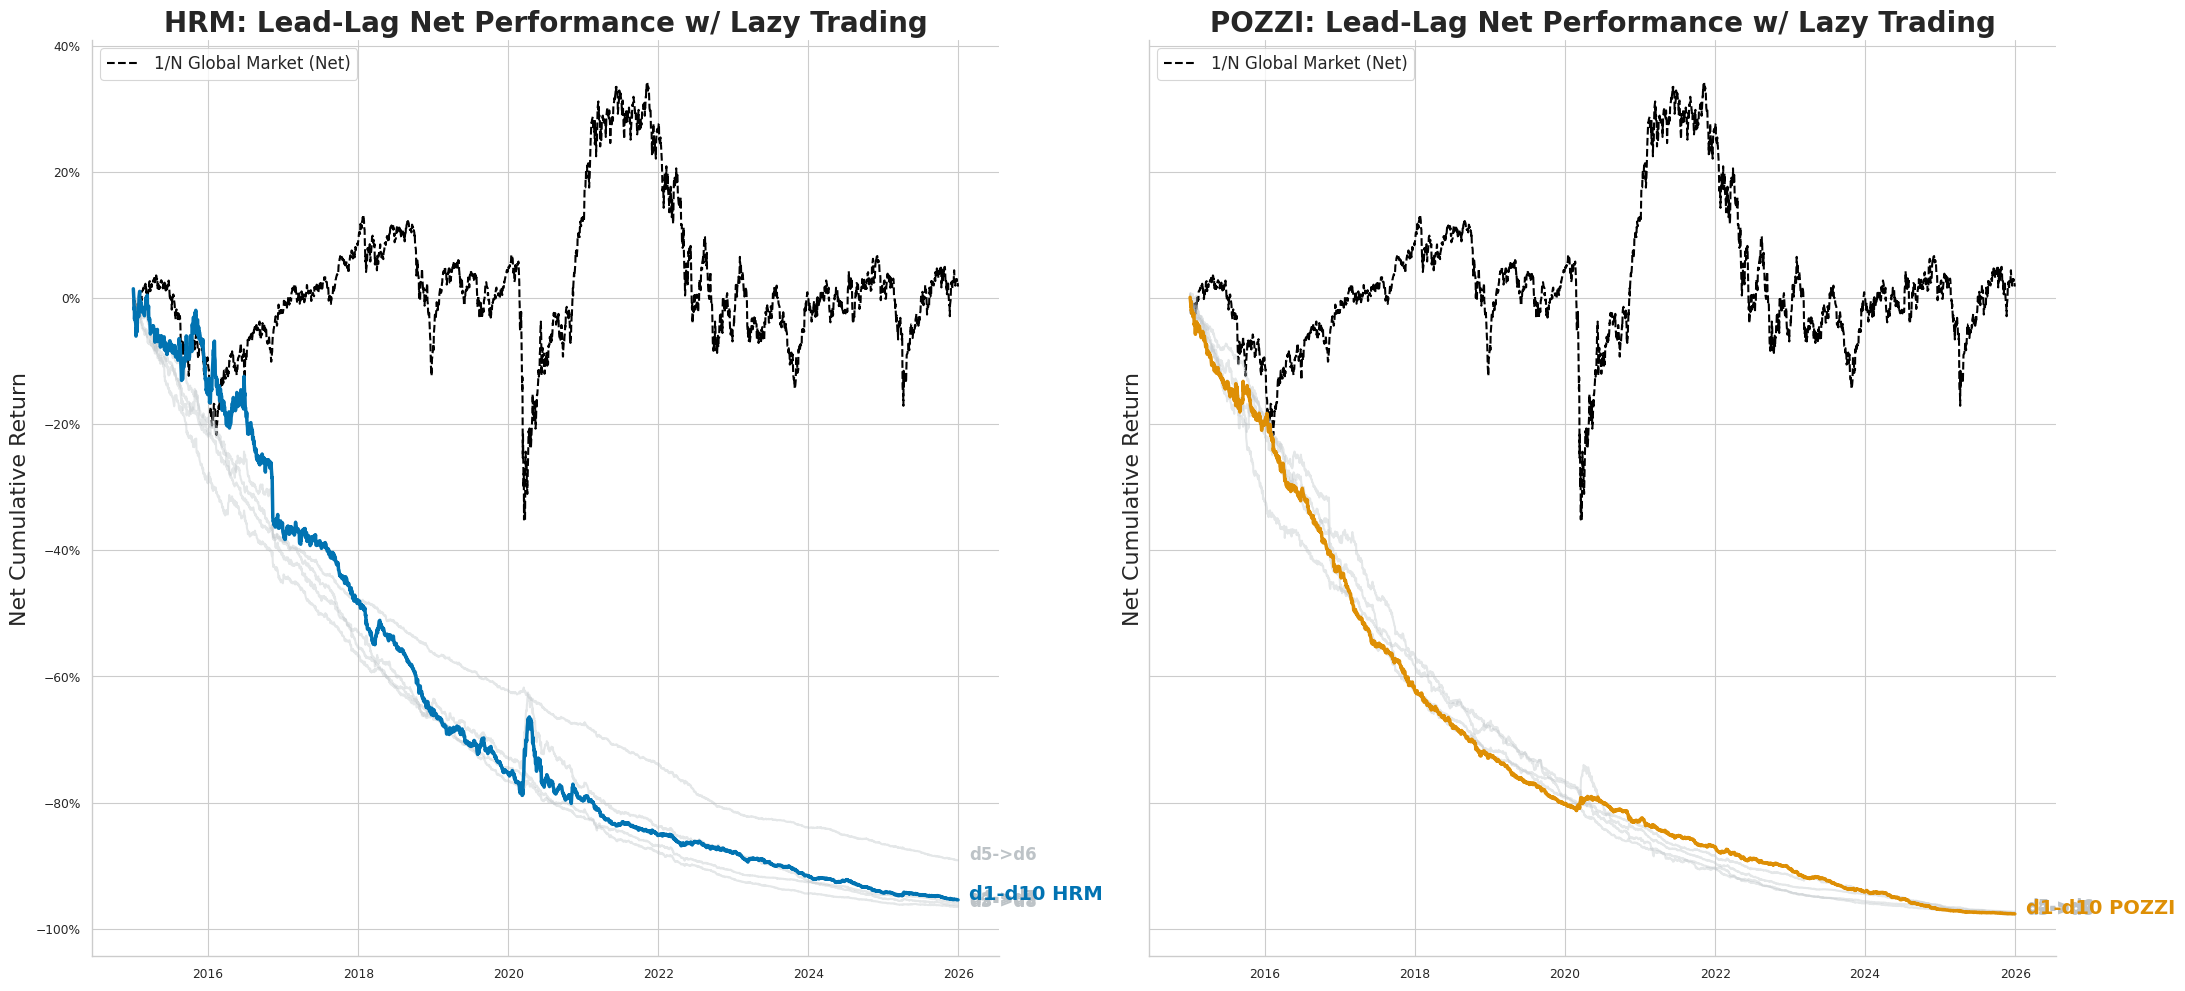

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO ---
years = range(2014, 2025)
k = 5
metrics = ["hrm", "pozzi"]
decile_pairs = [(i, 11 - i) for i in range(1, 6)] 
c = 0.001 # Custo de transação (10 bps)
threshold = 0.002 # Limite de inércia corrigido (20 bps).

def generate_lazy_signal(spread_series, threshold):
    """
    Gera um sinal de negociação usando histerese (bandas de inércia).
    Sempre começa posicionado (1 ou -1) e SÓ TROCA se o spread cruzar a banda oposta.
    """
    signal = np.zeros(len(spread_series))
    
    first_s = spread_series.iloc[0]
    current_pos = 1 if first_s >= 0 else -1
    
    for i in range(len(spread_series)):
        s = spread_series.iloc[i]
        
        if s > threshold:
            current_pos = 1
        elif s < -threshold:
            current_pos = -1
            
        signal[i] = current_pos
        
    return pd.Series(signal, index=spread_series.index)


# 1. Carregamento do Universo Total
df_ret_full = pd.read_parquet("../../data/01_raw/returns.parquet")
df_ret_full = df_ret_full[df_ret_full.index >= pd.Timestamp(2015, 1, 1)]

# Identifica globalmente o período ativo de cada ativo (excluindo os zeros de antes do IPO)
is_active = df_ret_full.notna() & (df_ret_full != 0).cummax()

# --- BENCHMARK 1/N GLOBAL COM CUSTOS DE TRANSAÇÃO ---
W_mkt = is_active.astype(float).div(is_active.sum(axis=1), axis=0)
R_mkt_all = df_ret_full.fillna(0)

W_mkt_drift = W_mkt.shift(1).fillna(0) * (1 + R_mkt_all.shift(1).fillna(0))
W_mkt_drift = W_mkt_drift.div(W_mkt_drift.sum(axis=1).replace(0, 1), axis=0)

turnover_mkt = (W_mkt - W_mkt_drift).abs().sum(axis=1).fillna(0)
market_benchmark_global_gross = np.log1p(df_ret_full.where(is_active)).mean(axis=1)
market_benchmark_global = market_benchmark_global_gross - (c * turnover_mkt)

results_strat = {m: {f"d{p}_d{c}": [] for p, c in decile_pairs} for m in metrics}

# --- LOOP DE BACKTEST (OUT-OF-SAMPLE) ---
for year in years:
    test_year = year + 1
    df_ret_oos = df_ret_full[df_ret_full.index.year == test_year]
    is_active_oos = is_active[is_active.index.year == test_year]
    
    if df_ret_oos.empty:
        continue

    for metric in metrics:
        for c_idx, p_idx in decile_pairs:
            try:
                c_label = f"decil_{c_idx}_{year}_{metric}"
                p_label = f"decil_{p_idx}_{year}_{metric}"
                
                cols_c = pd.read_parquet(f"../../data/06_portfolios/{c_label}.parquet").columns
                cols_p = pd.read_parquet(f"../../data/06_portfolios/{p_label}.parquet").columns
                
                valid_c = cols_c.intersection(df_ret_oos.columns)
                valid_p = cols_p.intersection(df_ret_oos.columns)

                # 2. CÁLCULO 1/N DINÂMICO
                # Zera os retornos das ações naqueles dias em que elas não deveriam existir
                ret_c_active = df_ret_oos[valid_c].where(is_active_oos[valid_c])
                ret_p_active = df_ret_oos[valid_p].where(is_active_oos[valid_p])
                
                # O .mean() vai tirar a média SÓ dos que não são NaNs (os ativos vivos no dia!)
                ret_c = np.log1p(ret_c_active).mean(axis=1).fillna(0)
                ret_p = np.log1p(ret_p_active).mean(axis=1).fillna(0)

                # --- ESTRATÉGIA COM LAZY SIGNAL (HISTERESE) ---
                spread = (ret_c - ret_p).shift(1).fillna(0)
                signal = generate_lazy_signal(spread, threshold)
                
                strat_ret_gross = (signal * (ret_p - ret_c)).fillna(0)
                
                # --- CUSTOS DE TRANSAÇÃO DA ESTRATÉGIA (DINÂMICO) ---
                # Cria a matriz de pesos 1/N diária considerando quais ações existem no dia
                W_c_active_mask = is_active_oos[valid_c].astype(float)
                W_p_active_mask = is_active_oos[valid_p].astype(float)
                
                # Divisão pelo número de ativos vivos naquele dia exato
                W_c_internal = W_c_active_mask.div(W_c_active_mask.sum(axis=1), axis=0).fillna(0)
                W_p_internal = W_p_active_mask.div(W_p_active_mask.sum(axis=1), axis=0).fillna(0)
                
                # Multiplica pela ponta da estratégia (Long vs Short)
                W_p_target = W_p_internal.multiply(signal, axis=0)
                W_c_target = W_c_internal.multiply(-signal, axis=0)
                W_target = W_p_target.add(W_c_target, fill_value=0)
                
                R_oos = df_ret_oos[W_target.columns].fillna(0)
                
                # Drift: Onde a carteira do fechamento de ontem abriu hoje antes do rebalanceamento
                W_drift = W_target.shift(1).fillna(0) * (1 + R_oos.shift(1).fillna(0))
                
                # Custo da mudança de sinal + Adição de Ativos Novos + Rebalanceamento diário
                turnover_strat = (W_target - W_drift).abs().sum(axis=1).fillna(0)
                strat_ret_net = strat_ret_gross - (c * turnover_strat)
                
                results_strat[metric][f"d{c_idx}_d{p_idx}"].append(strat_ret_net)
                
            except FileNotFoundError:
                continue

# --- CONSOLIDAÇÃO ---
final_results = {}
for m in metrics:
    for pair_key in results_strat[m]:
        if results_strat[m][pair_key]:
            final_results[f"{m}_{pair_key}"] = pd.concat(results_strat[m][pair_key])

# --- VISUALIZAÇÃO ---
sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(1, 2, figsize=(22, 10), sharey=True)
palette = sns.color_palette("colorblind")

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    common_idx = final_results[f"{metric}_d1_d10"].index
    mkt_plot = market_benchmark_global.loc[common_idx]
    cum_market = np.exp(mkt_plot.cumsum()) - 1
    ax.plot(cum_market.index, cum_market, color='black', lw=1.5, ls='--', label='1/N Global Market (Net)')

    for c_idx, p_idx in decile_pairs[1:]:
        pair_key = f"{metric}_d{c_idx}_d{p_idx}"
        if pair_key in final_results:
            rets = final_results[pair_key]
            cum_rets = np.exp(rets.cumsum()) - 1
            ax.plot(cum_rets.index, cum_rets, color='#BDC3C7', lw=1.5, alpha=0.4)
            ax.annotate(f"d{c_idx}->d{p_idx}", xy=(cum_rets.index[-1], cum_rets.iloc[-1]), 
                xytext=(8, 0), textcoords='offset points', fontsize=12, fontweight='bold', color='#BDC3C7')

    pair_main = f"{metric}_d1_d10"
    if pair_main in final_results:
        rets = final_results[pair_main]
        cum_rets = np.exp(rets.cumsum()) - 1
        ax.plot(cum_rets.index, cum_rets, color=palette[idx], lw=2.5, zorder=5)
        ax.annotate(f"d1-d10 {metric.upper()}", xy=(cum_rets.index[-1], cum_rets.iloc[-1]), 
                    xytext=(8, 0), textcoords='offset points', fontsize=14, fontweight='bold', color=palette[idx])

    ax.set_title(f"{metric.upper()}: Lead-Lag Net Performance w/ Lazy Trading", fontsize=20, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel("Net Cumulative Return", fontsize=16)
    ax.legend(loc='upper left', fontsize=12)

sns.despine()
plt.tight_layout()
plt.savefig("../../figures/strategy_lazy_net.png", dpi=300)
plt.show()

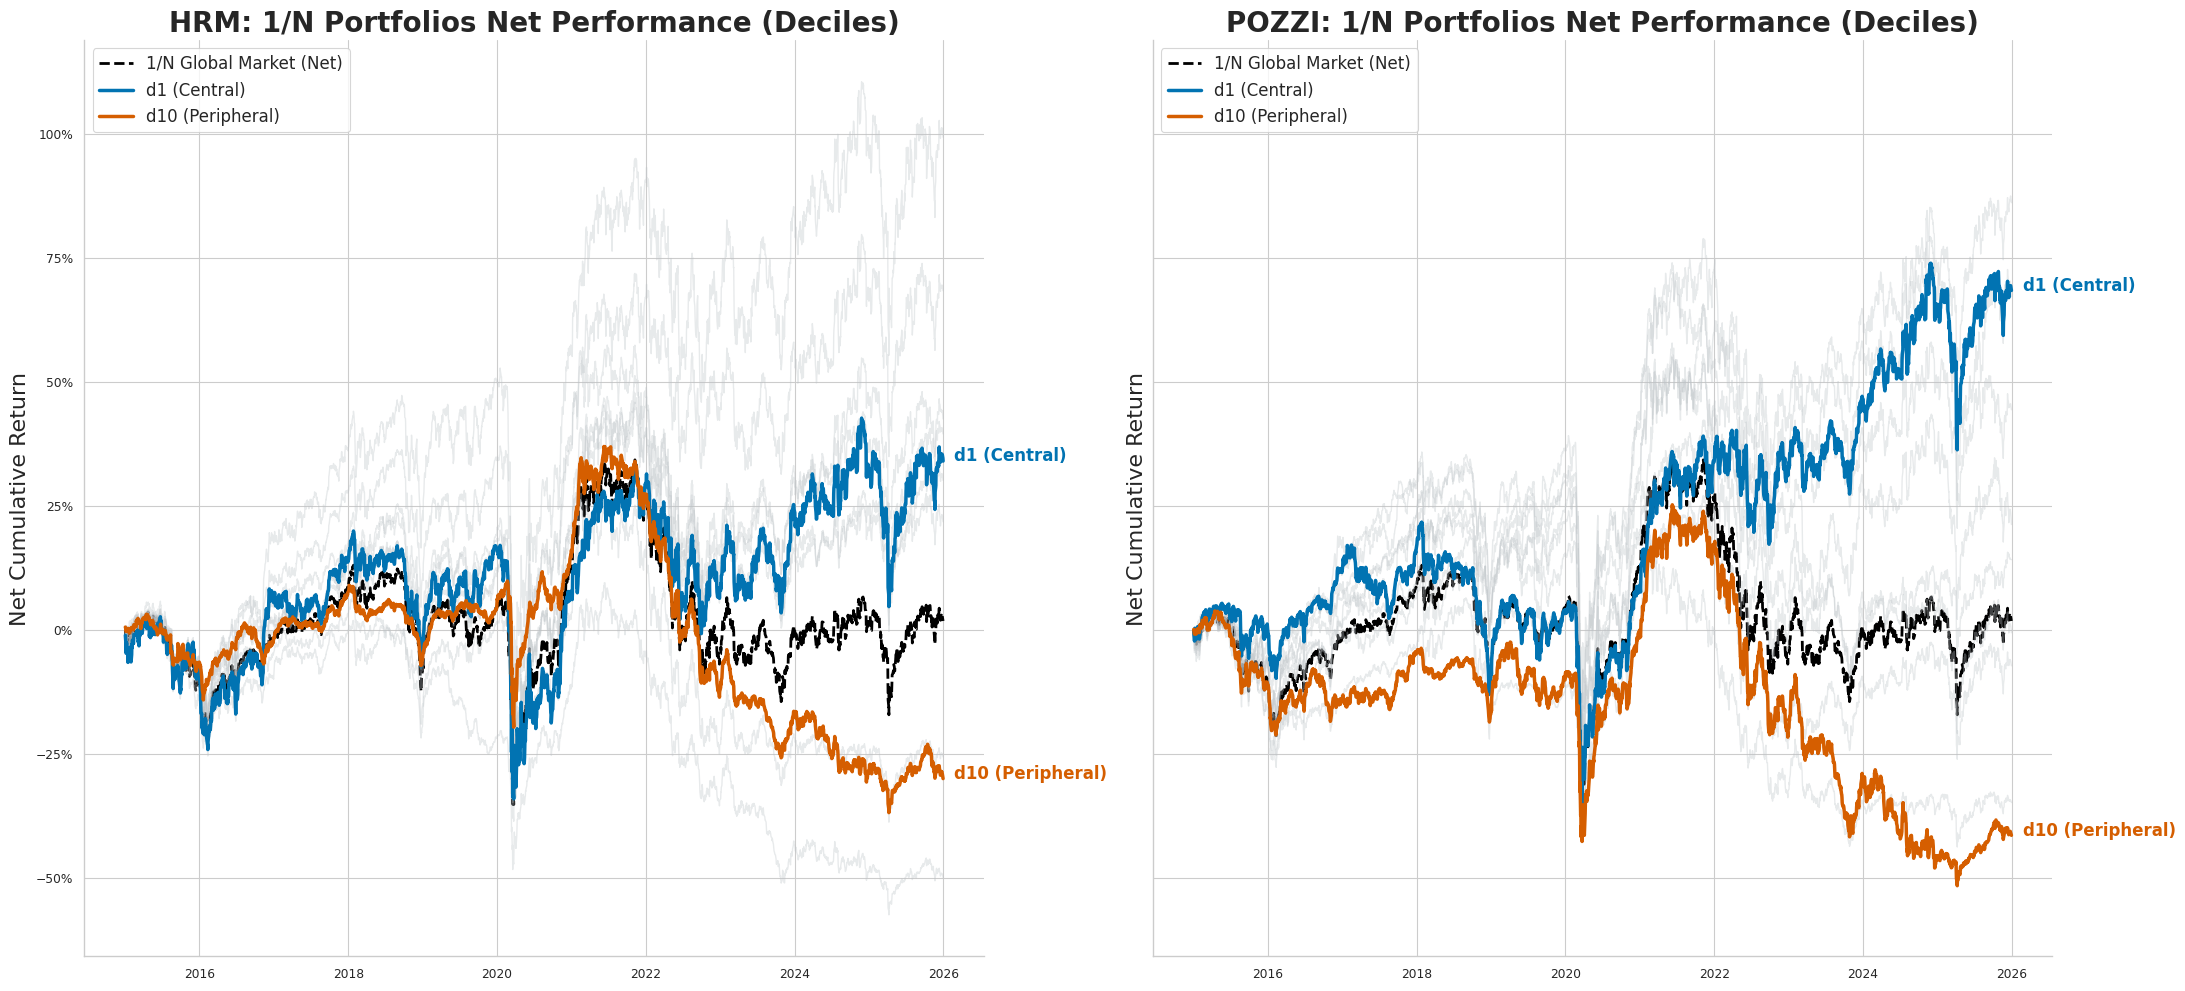

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO ---
years = range(2014, 2025)
metrics = ["hrm", "pozzi"]
deciles = range(1, 11) # Decis de 1 a 10
c = 0.001 # Custo de transação (10 bps)

# 1. Carregamento do Universo Total
df_ret_full = pd.read_parquet("../../data/01_raw/returns.parquet")
df_ret_full = df_ret_full[df_ret_full.index >= pd.Timestamp(2015, 1, 1)]

# Identifica globalmente o período ativo de cada ativo
is_active = df_ret_full.notna() & (df_ret_full != 0).cummax()

# --- BENCHMARK 1/N GLOBAL COM CUSTOS DE TRANSAÇÃO ---
W_mkt = is_active.astype(float).div(is_active.sum(axis=1), axis=0)
R_mkt_all = df_ret_full.fillna(0)

W_mkt_drift = W_mkt.shift(1).fillna(0) * (1 + R_mkt_all.shift(1).fillna(0))
W_mkt_drift = W_mkt_drift.div(W_mkt_drift.sum(axis=1).replace(0, 1), axis=0)

turnover_mkt = (W_mkt - W_mkt_drift).abs().sum(axis=1).fillna(0)
market_benchmark_global_gross = np.log1p(df_ret_full.where(is_active)).mean(axis=1)
market_benchmark_global = market_benchmark_global_gross - (c * turnover_mkt)

# Dicionário para guardar as séries de retorno de todos os decis
results_deciles = {m: {f"d{d}": [] for d in deciles} for m in metrics}

# --- LOOP DE BACKTEST (OUT-OF-SAMPLE) ---
for year in years:
    test_year = year + 1
    df_ret_oos = df_ret_full[df_ret_full.index.year == test_year]
    is_active_oos = is_active[is_active.index.year == test_year]
    
    if df_ret_oos.empty:
        continue

    for metric in metrics:
        for d_idx in deciles:
            try:
                d_label = f"decil_{d_idx}_{year}_{metric}"
                
                cols_d = pd.read_parquet(f"../../data/06_portfolios/{d_label}.parquet").columns
                valid_d = cols_d.intersection(df_ret_oos.columns)

                # 2. CÁLCULO DO RETORNO 1/N DO DECIL (GROSS)
                # O .where ignora retornos "falsos" (antes de a ação começar a existir ou pós deslistagem)
                ret_d_active = df_ret_oos[valid_d].where(is_active_oos[valid_d])
                ret_d_gross = np.log1p(ret_d_active).mean(axis=1).fillna(0)

                # --- CUSTOS DE TRANSAÇÃO DO DECIL (DINÂMICO) ---
                # Cria a matriz de pesos alvo (1/N exato para os ativos "vivos" daquele dia)
                W_d_active_mask = is_active_oos[valid_d].astype(float)
                W_d_target = W_d_active_mask.div(W_d_active_mask.sum(axis=1), axis=0).fillna(0)
                
                R_oos_d = df_ret_oos[valid_d].fillna(0)
                
                # Pesos driftados: a carteira de ontem com os rendimentos de ontem
                W_d_drift = W_d_target.shift(1).fillna(0) * (1 + R_oos_d.shift(1).fillna(0))
                
                # Normalização: numa carteira Long-Only fechada, a soma dos pesos volta pra 100% (1.0)
                W_d_drift = W_d_drift.div(W_d_drift.sum(axis=1).replace(0, 1), axis=0)
                
                # Turnover absoluto (Mede o quanto rebalanceamos internamente + entradas/saídas)
                turnover_d = (W_d_target - W_d_drift).abs().sum(axis=1).fillna(0)
                
                # Retorno líquido final (Net of Fees)
                ret_d_net = ret_d_gross - (c * turnover_d)
                
                results_deciles[metric][f"d{d_idx}"].append(ret_d_net)
                
            except FileNotFoundError:
                continue

# --- CONSOLIDAÇÃO ---
final_results = {}
for m in metrics:
    for d_key in results_deciles[m]:
        if results_deciles[m][d_key]:
            final_results[f"{m}_{d_key}"] = pd.concat(results_deciles[m][d_key])

# --- VISUALIZAÇÃO ---
sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(1, 2, figsize=(22, 10), sharey=True)
palette = sns.color_palette("colorblind")

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Usa o d1 como referência de índice para alinhar as datas
    common_idx = final_results[f"{metric}_d1"].index
    
    # 1. Benchmark Global 1/N
    mkt_plot = market_benchmark_global.loc[common_idx]
    cum_market = np.exp(mkt_plot.cumsum()) - 1
    ax.plot(cum_market.index, cum_market, color='black', lw=2, ls='--', label='1/N Global Market (Net)')

    # 2. Plotar os Decis Intermediários (Visual 'Faded')
    for d_idx in range(2, 10):
        d_key = f"{metric}_d{d_idx}"
        if d_key in final_results:
            rets = final_results[d_key]
            cum_rets = np.exp(rets.cumsum()) - 1
            ax.plot(cum_rets.index, cum_rets, color='#BDC3C7', lw=1.0, alpha=0.35)

    # 3. Destacar Decil 1 (Central) e Decil 10 (Peripheral)
    for d_idx, color, label_text in [(1, palette[0], "d1 (Central)"), (10, palette[3], "d10 (Peripheral)")]:
        d_key = f"{metric}_d{d_idx}"
        if d_key in final_results:
            rets = final_results[d_key]
            cum_rets = np.exp(rets.cumsum()) - 1
            ax.plot(cum_rets.index, cum_rets, color=color, lw=2.5, label=f'{label_text}')
            
            # Label point no final do gráfico
            ax.annotate(label_text, xy=(cum_rets.index[-1], cum_rets.iloc[-1]), 
                        xytext=(8, 0), textcoords='offset points', fontsize=12, fontweight='bold', color=color)

    ax.set_title(f"{metric.upper()}: 1/N Portfolios Net Performance (Deciles)", fontsize=20, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel("Net Cumulative Return", fontsize=16)
    ax.legend(loc='upper left', fontsize=12)

sns.despine()
plt.tight_layout()
plt.savefig("../../figures/deciles_1n_net.png", dpi=300)
plt.show()